**Level 2 – Task 1: Regression Analysis**

In this task, a linear regression model is built to analyze the relationship between housing features and price.

**Import Libraries**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**Load Dataset**

In [18]:
url = "https://drive.google.com/uc?id=1IECNCSJn3j0K-FuJLTqXoMQ6MD_Nezf3"

df = pd.read_csv(url, sep=r"\s+", header=None)

In [19]:
df.columns = [
    "CRIM","ZN","INDUS","CHAS","NOX","RM","AGE",
    "DIS","RAD","TAX","PTRATIO","B","LSTAT","PRICE"
]

In [20]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


**Data Understanding**

In [21]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


**Feature Selection**

For this analysis, RM (number of rooms) is selected as the independent variable, and PRICE is selected as the dependent variable.

In [22]:
X = df[['RM']]
y = df['PRICE']

**Train-Test Split**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Model Building**

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Prediction**

In [25]:
y_pred = model.predict(X_test)

**Results Comparison**

In [26]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
results.head()

,Actual,Predicted
0,23.6,23.732383
1,32.4,26.929502
2,13.6,19.684568
3,22.8,20.451129
4,16.1,22.619935


In [27]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 46.144775347317264
R2 Score: 0.3707569232254778


**Model Interpretation**

In [28]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 9.348301406497727
Intercept: -36.24631889813795


**Model Evaluation**

In [29]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 46.144775347317264
R2 Score: 0.3707569232254778


**Visualization**

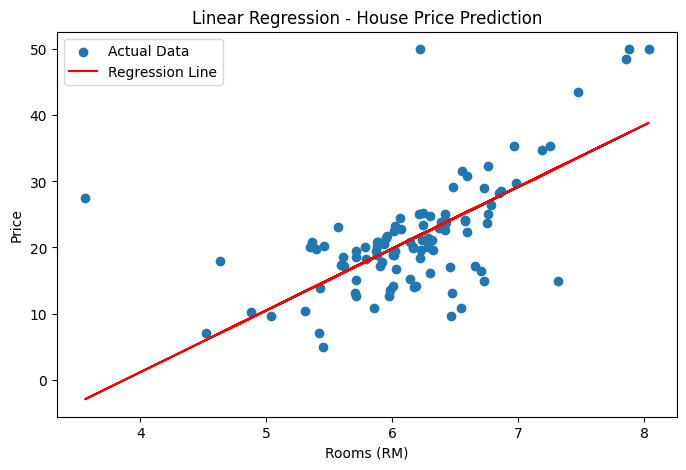

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, label="Actual Data")
plt.plot(X_test, y_pred, color="red", label="Regression Line")
plt.xlabel("Rooms (RM)")
plt.ylabel("Price")
plt.title("Linear Regression - House Price Prediction")
plt.legend()
plt.show()

**Conclusion**

In this task, a simple linear regression model was developed to predict house prices based on the number of rooms. The results indicate a positive relationship between the number of rooms and house price. The model was evaluated using MSE and R² score, and it provides a reasonable prediction performance. This analysis demonstrates how linear regression can be used for understanding relationships in real-world datasets.